
Processing Ast...
  Overlap genes: 43

Processing Mic...
  Overlap genes: 50

Processing In...
  Overlap genes: 14

Processing Oli...
  Overlap genes: 108

Processing Opc...
  Overlap genes: 33

Processing Ex...
  Overlap genes: 33


/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/n/groups/patel/adithya/scenv/lib64/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"]

<Figure size 1000x600 with 0 Axes>

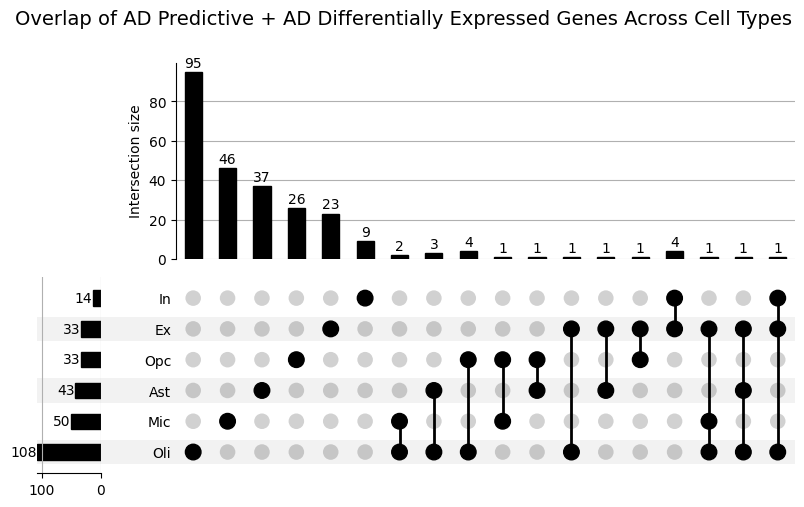


 UpSet plot saved to: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/upset_overlap_plot.png


In [1]:
# upset plot
import os
import pandas as pd
import joblib
from collections import defaultdict
from matplotlib import pyplot as plt
from upsetplot import from_contents, UpSet
# reran aug 11th

# === Paths ===
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
de_base_dir = "/n/scratch/users/a/adm808/Revision/Clincal_batch_DE_Outputs_revision"
out_fig_path = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/upset_overlap_plot.png"

# === Cell types ===
cell_types = ["Ast", "Mic", "In", "Oli", "Opc", "Ex"]

# === DE result files ===
de_files = {
    "Ast": "poisson_DE_results_Ast.csv",
    "Mic": "poisson_DE_results_Mic.csv",
    "In": "poisson_DE_results_In.csv",
    "Oli": "poisson_DE_results_Oli.csv",
    "Opc": "poisson_DE_results_Opc.csv",
    "Ex": "poisson_DE_results_Ex.csv"
}

# === Initialize dictionaries to store gene sets ===
predictive_de_overlap_dict = {}

# === Loop through each cell type ===
for cell_type_short in cell_types:
    print(f"\nProcessing {cell_type_short}...")

    # --- Predictive genes from model ---
    gene_presence = defaultdict(int)
    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type_short, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            continue
        model = joblib.load(joblib_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_
        for gene, imp in zip(feature_names, importances):
            if imp > 0:
                gene_presence[gene.upper()] += 1
    predictive_genes = {gene for gene, count in gene_presence.items() if count >= 2}

    # --- Differentially expressed genes (p_adj < 0.05 only) ---
    de_path = os.path.join(de_base_dir, de_files[cell_type_short])
    df = pd.read_csv(de_path)
    df = df[df["p_adj"].notnull()]
    df["gene_upper"] = df["gene"].str.upper()

    # de_genes = set(df[df["p_adj"] < 0.05]["gene_upper"])
    de_genes = set(df[(df["p_adj"] < 0.05) & (df["log2FC"].abs() > 0.25)]["gene_upper"])

    # --- Overlap ---
    overlap_genes = predictive_genes & de_genes
    predictive_de_overlap_dict[cell_type_short] = overlap_genes
    print(f"  Overlap genes: {len(overlap_genes)}")

# === Create UpSet plot ===
contents = {k: v for k, v in predictive_de_overlap_dict.items() if len(v) > 0}

upset_data = from_contents(contents)
plt.figure(figsize=(10, 6))
upset = UpSet(upset_data, subset_size='count', show_counts=True, sort_by='degree')
upset.plot()

# === annotate small intersections ===
# find the Axes that has the bar chart

plt.suptitle("Overlap of AD Predictive + AD Differentially Expressed Genes Across Cell Types", fontsize=14)
# plt.savefig(out_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"\n UpSet plot saved to: {out_fig_path}")

In [2]:
import os
import pandas as pd
import joblib
from collections import defaultdict

# === Paths ===
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
de_base_dir = "/n/scratch/users/a/adm808/Revision/Clincal_batch_DE_Outputs_revision"

# === Cell types and DE files ===
cell_types = ["Ast", "Mic", "In", "Oli", "Opc", "Ex"]
de_files = {
    "Ast": "poisson_DE_results_Ast.csv",
    "Mic": "poisson_DE_results_Mic.csv",
    "In": "poisson_DE_results_In.csv",
    "Oli": "poisson_DE_results_Oli.csv",
    "Opc": "poisson_DE_results_Opc.csv",
    "Ex": "poisson_DE_results_Ex.csv"
}

# === Calculate percentage overlap ===
for cell_type_short in cell_types:
    # --- Predictive genes ---
    gene_presence = defaultdict(int)
    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type_short, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            continue
        model = joblib.load(joblib_path)
        for gene, imp in zip(model.feature_names_in_, model.feature_importances_):
            if imp > 0:
                gene_presence[gene.upper()] += 1
    predictive_genes = {g for g, count in gene_presence.items() if count >= 2}

    # --- DEGs ---
    de_path = os.path.join(de_base_dir, de_files[cell_type_short])
    df = pd.read_csv(de_path)
    df = df[df["p_adj"].notnull()]
    # de_genes = set(df[(df["p_adj"] < 0.05) & (df["log2FC"].abs() > 0.25)]["gene_upper"])
    # de_genes = set(df.loc[df["p_adj"] < 0.05, "gene"].str.upper())
    df["gene_upper"] = df["gene"].str.upper()
    de_genes = set(df[(df["p_adj"] < 0.05) & (df["log2FC"].abs() > 0.25)]["gene_upper"])

    # --- Percentage overlap ---
    overlap_count = len(predictive_genes & de_genes)
    total_predictive = len(predictive_genes)
    percent_overlap = (overlap_count / total_predictive * 100) if total_predictive > 0 else 0

    print(f"{cell_type_short}: {percent_overlap:.2f}% of predictive genes were DEGs "
          f"({overlap_count}/{total_predictive})")

Ast: 24.57% of predictive genes were DEGs (43/175)
Mic: 10.73% of predictive genes were DEGs (50/466)
In: 12.96% of predictive genes were DEGs (14/108)
Oli: 17.39% of predictive genes were DEGs (108/621)
Opc: 3.95% of predictive genes were DEGs (33/835)
Ex: 20.37% of predictive genes were DEGs (33/162)


          Down   Up
CellType           
Ast         64  114
Ex         363  703
In         141   99
Mic         53   35
Oli        274  437
Opc         16   48


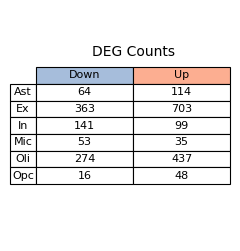

Table figure saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/deg_counts_table_style.png


In [3]:
# deg table
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
# reran aug11th

# === Paths ===
de_base_dir = "/n/scratch/users/a/adm808/Revision/Clincal_batch_DE_Outputs_revision"
out_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/"
os.makedirs(out_dir, exist_ok=True)

# === Cell types ===
cell_types = ["Ast", "Ex", "In", "Mic", "Oli", "Opc"]
de_files = {
    "Ast": "poisson_DE_results_Ast.csv",
    "Mic": "poisson_DE_results_Mic.csv",
    "In": "poisson_DE_results_In.csv",
    "Oli": "poisson_DE_results_Oli.csv",
    "Opc": "poisson_DE_results_Opc.csv",
    "Ex": "poisson_DE_results_Ex.csv"
}

# === DEG count summary DataFrame (strict cutoff) ===
deg_summary = []

for ct in cell_types:
    df = pd.read_csv(os.path.join(de_base_dir, de_files[ct]))
    df = df[(df["p_adj"] < 0.05) & (abs(df["log2FC"]) > 0.25)]
    up_count = (df["log2FC"] > 0.25).sum()
    down_count = (df["log2FC"] < -0.25).sum()
    deg_summary.append({"CellType": ct, "Down": down_count, "Up": up_count})

deg_summary_df = pd.DataFrame(deg_summary).set_index("CellType")
print(deg_summary_df)

# === Plot table-like figure ===
fig, ax = plt.subplots(figsize=(2.5, 3))
ax.axis('off')

# Convert to string for table
cell_text = deg_summary_df.astype(str).values.tolist()

# Create table
table = ax.table(
    cellText=cell_text,
    rowLabels=deg_summary_df.index,
    colLabels=["Down", "Up"],
    cellLoc='center',
    rowLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8)

# Add thin black grid lines and adjust scaling
for (row, col), cell in table.get_celld().items():
    cell.set_linewidth(0.8)
    cell.set_edgecolor('black')
    cell.set_facecolor('white')

# Shade header cells: row 0
soft_blue = "#a6bddb"   # muted blue
soft_red = "#fcae91"    # muted red

table[(0, 0)].set_facecolor(soft_blue)  # Down
table[(0, 1)].set_facecolor(soft_red)   # Up

# No rotation of headers
for col in range(len(deg_summary_df.columns)):
    header_cell = table[(0, col)]
    header_cell.get_text().set_rotation(0)

# Title "DEGs" centered above
plt.text(0.5, 0.8, "DEG Counts", fontsize=10, ha='center', transform=ax.transAxes)

plt.savefig(os.path.join(out_dir, "deg_counts_table_style.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"Table figure saved to {os.path.join(out_dir, 'deg_counts_table_style.png')}")

In [4]:
import os
import pandas as pd

# === Paths ===
de_base_dir = "/n/scratch/users/a/adm808/Revision/Clincal_batch_DE_Outputs_revision"
cell_types = ["Ast", "Ex", "In", "Mic", "Oli", "Opc"]
de_files = {
    "Ast": "poisson_DE_results_Ast.csv",
    "Mic": "poisson_DE_results_Mic.csv",
    "In": "poisson_DE_results_In.csv",
    "Oli": "poisson_DE_results_Oli.csv",
    "Opc": "poisson_DE_results_Opc.csv",
    "Ex": "poisson_DE_results_Ex.csv"
}

# === Collect all DEGs ===
all_degs = set()

for ct in cell_types:
    df = pd.read_csv(os.path.join(de_base_dir, de_files[ct]))
    # Apply cutoff
    degs = df[(df["p_adj"] < 0.05) & (abs(df["log2FC"]) > 0.25)]
    # Store gene names (case-insensitive)
    all_degs.update(degs["gene"].str.upper())

# === Count and print ===
print(f"Total unique DEGs across all cell types: {len(all_degs)}")

Total unique DEGs across all cell types: 2060


In [ ]:
# # Wait for CERAD with RE to finish -- delete this comment once changed
# import os
# import pandas as pd

# # === Paths ===
# de_base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/Differential_Expression_Final/CERAD/"
# cell_types = ["Ast", "Ex", "In", "Mic", "Oli", "Opc"]
# de_files = {
#     "Ast": "poisson_DE_results_Ast.csv",
#     "Mic": "poisson_DE_results_Mic.csv",
#     "In": "poisson_DE_results_In.csv",
#     "Oli": "poisson_DE_results_Oli.csv",
#     "Opc": "poisson_DE_results_Opc.csv",
#     "Ex": "poisson_DE_results_Ex.csv"
# }

# # === Collect all DEGs ===
# all_degs = set()

# for ct in cell_types:
#     df = pd.read_csv(os.path.join(de_base_dir, de_files[ct]))
#     # Apply cutoff
#     degs = df[(df["p_adj"] < 0.05) & (abs(df["log2FC"]) > 0.25)]
#     # Store gene names (case-insensitive)
#     all_degs.update(degs["gene"].str.upper())

# # === Count and print ===
# print(f"Total unique DEGs across all cell types: {len(all_degs)}")

Astrocytes: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/overlap_pred_DE_Ast.csv


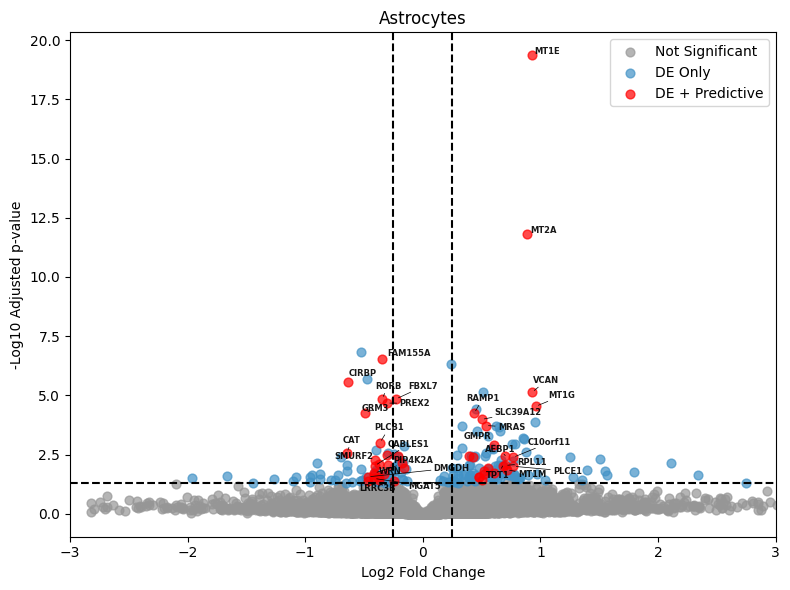

Astrocytes: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/volcano_Ast_pred_marked.png
Microglia: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/overlap_pred_DE_Mic.csv


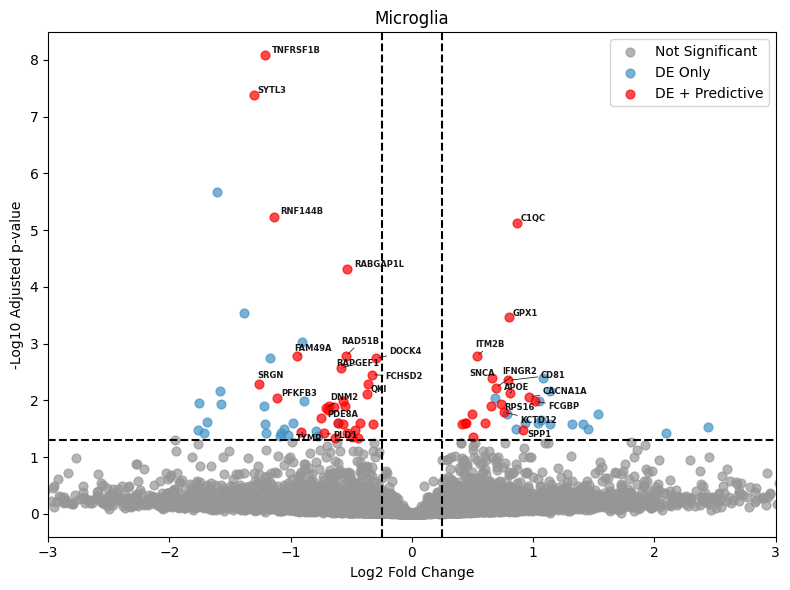

Microglia: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/volcano_Mic_pred_marked.png
Inhibitory Neurons: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/overlap_pred_DE_In.csv


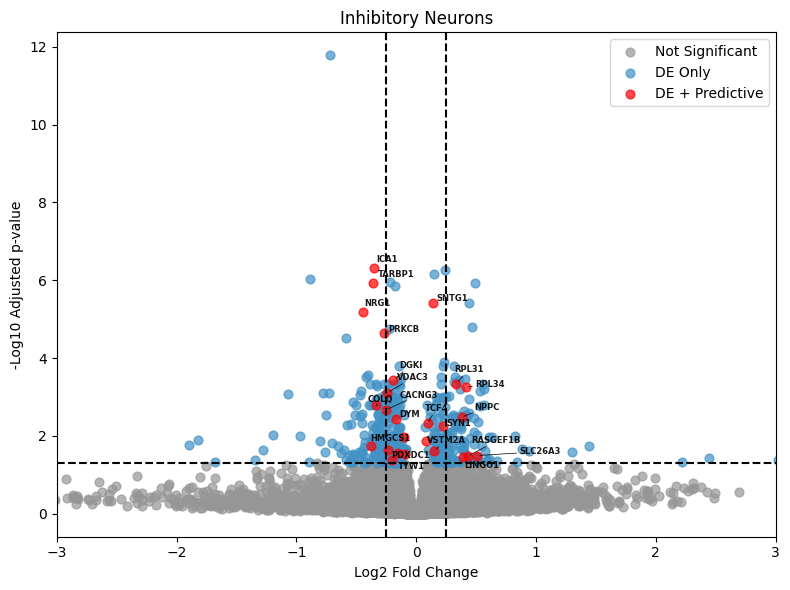

Inhibitory Neurons: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/volcano_In_pred_marked.png
Oligodendrocytes: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/overlap_pred_DE_Oli.csv


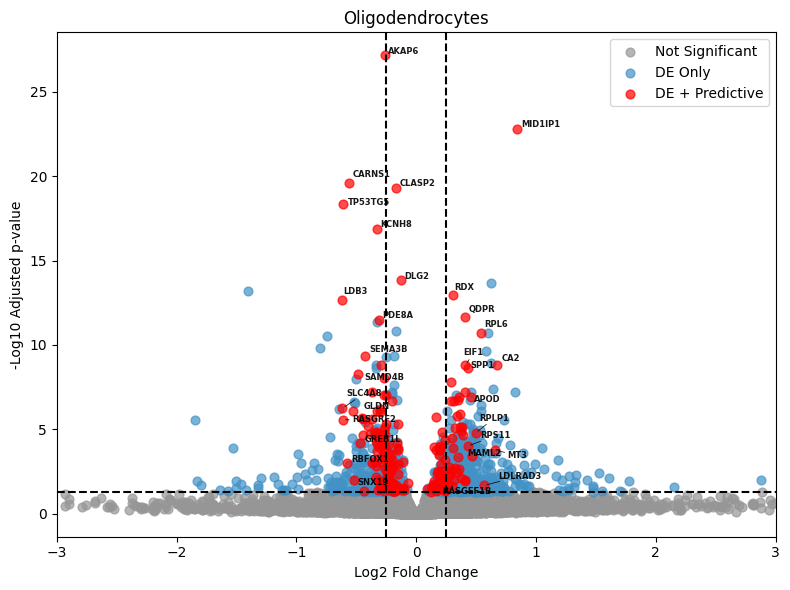

Oligodendrocytes: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/volcano_Oli_pred_marked.png
Oligodendrocyte Progenitor Cells: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/overlap_pred_DE_Opc.csv


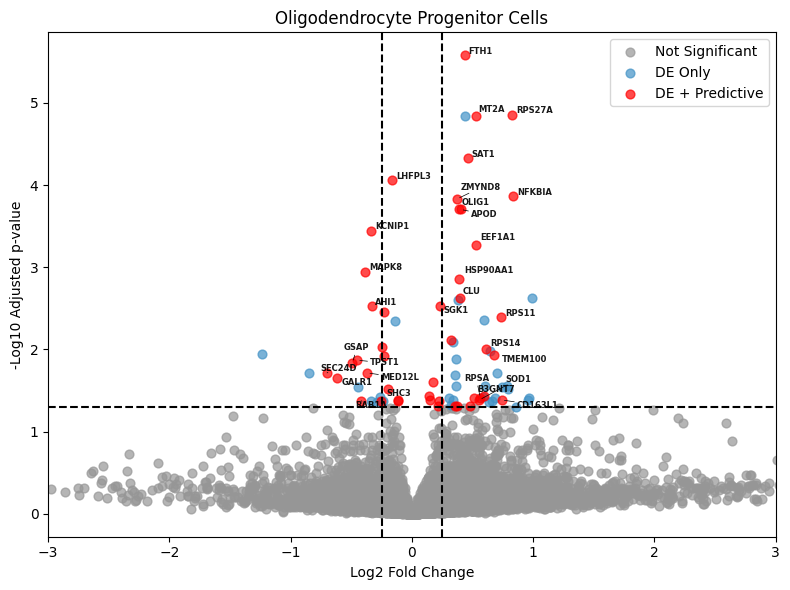

Oligodendrocyte Progenitor Cells: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/volcano_Opc_pred_marked.png
Excitatory Neurons: Overlap genes saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/overlap_pred_DE_Ex.csv


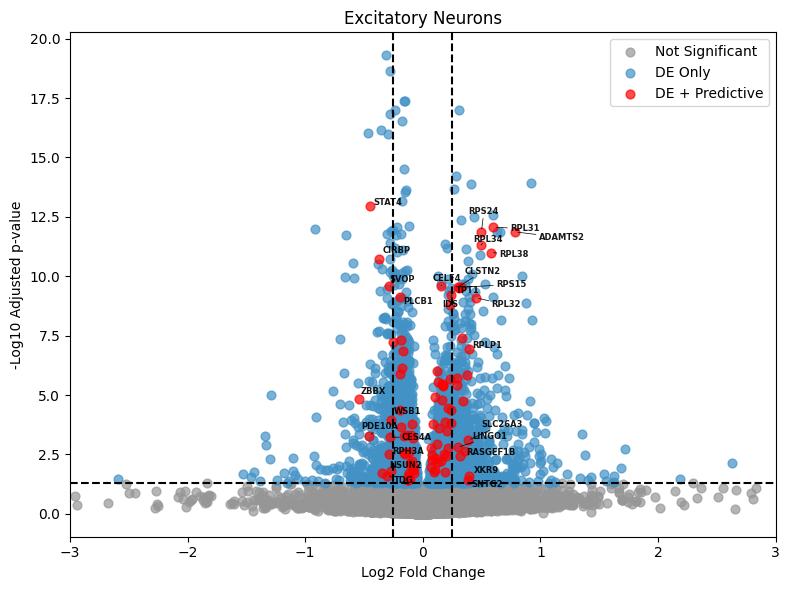

Excitatory Neurons: Volcano plot saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/volcano_Ex_pred_marked.png
Overlap CSVs and volcano plots saved for all cell types!


In [10]:
# volcano plots
import os
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from adjustText import adjust_text

# === Paths ===
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
de_base_dir = "/n/scratch/users/a/adm808/Revision/Clincal_batch_DE_Outputs_revision"
out_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/"
fig_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/"
os.makedirs(out_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

# === Cell types ===
ct_labels = {
    'Ast': 'Astrocytes',
    'Mic': 'Microglia',
    'In': 'Inhibitory Neurons',
    'Oli': 'Oligodendrocytes',
    'Opc': 'Oligodendrocyte Progenitor Cells',
    'Ex': 'Excitatory Neurons'
}
cell_types = list(ct_labels.keys())

# === DE result files ===
de_files = {
    "Ast": "poisson_DE_results_Ast.csv",
    "Mic": "poisson_DE_results_Mic.csv",
    "In": "poisson_DE_results_In.csv",
    "Oli": "poisson_DE_results_Oli.csv",
    "Opc": "poisson_DE_results_Opc.csv",
    "Ex": "poisson_DE_results_Ex.csv"
}

# === Store predictive genes ===
predictive_genes_dict = {}

# === Process each cell type ===
for cell_type_short in cell_types:
    # --- Build predictive genes using your logic ---
    gene_presence = defaultdict(int)
    for split in range(1, 6):
        joblib_path = os.path.join(base_dir, cell_type_short, f"split_{split}", "maximal_classifier.joblib")
        if not os.path.exists(joblib_path):
            continue
        model = joblib.load(joblib_path)
        feature_names = model.feature_names_in_
        importances = model.feature_importances_
        for gene, imp in zip(feature_names, importances):
            if imp > 0:
                gene_presence[gene.upper()] += 1
    predictive_genes = {gene for gene, count in gene_presence.items() if count >= 2}
    predictive_genes_dict[cell_type_short] = predictive_genes

    # --- Load DE genes ---
    de_path = os.path.join(de_base_dir, de_files[cell_type_short])
    df = pd.read_csv(de_path)
    df = df[df["p_adj"].notnull() & df["log2FC"].notnull()]
    # Drop genes with p_adj == 0 because -log10(0) = inf breaks plotting
    df = df[df["p_adj"] > 0]
    df["gene_upper"] = df["gene"].str.upper()

    # --- Identify DE genes (FDR adjusted p-values) ---
    de_genes = set(df[df["p_adj"] < 0.05]["gene_upper"])

    # --- Find overlap ---
    overlap_genes = predictive_genes & de_genes

    # --- Save overlap CSV ---
    overlap_df = df[df["gene_upper"].isin(overlap_genes)].copy()
    overlap_df = overlap_df[["gene", "p_adj"]].sort_values("p_adj")
    out_path = os.path.join(out_dir, f"overlap_pred_DE_{cell_type_short}.csv")
    overlap_df.to_csv(out_path, index=False)
    print(f"{ct_labels[cell_type_short]}: Overlap genes saved to {out_path}")

    # === Volcano plot ===
    df["-log10_padj"] = -np.log10(df["p_adj"])
    df = df[df["log2FC"].abs() <= 20]

    # Thresholds
    logfc_thresh = 0.25
    pval_thresh = 0.05

    # Group assignment
    df["group"] = "Not Significant"
    df.loc[(df["p_adj"] < pval_thresh) & (~df["gene_upper"].isin(predictive_genes)), "group"] = "DE Only"
    df.loc[(df["p_adj"] < pval_thresh) & (df["gene_upper"].isin(predictive_genes)), "group"] = "DE + Predictive"

    # Color map
    color_map = {
        "Not Significant": "#969696",
        "DE Only": "#4292c6",
        "DE + Predictive": "red"
    }

    plt.figure(figsize=(8, 6))

    for group, color in color_map.items():
        subset = df[df["group"] == group]
        plt.scatter(subset["log2FC"], subset["-log10_padj"], color=color, alpha=0.7, s=40, label=group)

    df = df[df["log2FC"].between(-3, 3)]

    plt.xlim(-3, 3)
    plt.axvline(x=logfc_thresh, color='black', linestyle='--')
    plt.axvline(x=-logfc_thresh, color='black', linestyle='--')
    plt.axhline(y=-np.log10(pval_thresh), color='black', linestyle='--')

    # Label DE + Predictive genes
    label_df = df[df["group"] == "DE + Predictive"]

    top_padj = label_df.nsmallest(15, "p_adj")
    top_up = label_df.nlargest(10, "log2FC")
    top_down = label_df.nsmallest(10, "log2FC")

    final_label_df = pd.concat([top_padj, top_up, top_down]).drop_duplicates(subset="gene_upper")

    # >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
    # ALWAYS label these genes ONLY IF they are BOTH predictive AND DEG
    always_label = ["ARL17B", "LINGO1", "RASGEF1B"]
    extra_label_df = df[
        (df["gene_upper"].isin(always_label)) &
        (df["group"] == "DE + Predictive")
    ]

    if not extra_label_df.empty:
        final_label_df = pd.concat(
            [final_label_df, extra_label_df]
        ).drop_duplicates(subset="gene_upper")
    # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

    if cell_type_short == 'Mic':
        apoe_rows = df[df['gene_upper'] == 'APOE']
        if not apoe_rows.empty:
            final_label_df = pd.concat([final_label_df, apoe_rows]).drop_duplicates(subset="gene_upper")
            plt.scatter(apoe_rows["log2FC"], apoe_rows["-log10_padj"],
                        s=40, facecolors='none', edgecolors='none', linewidths=1.2, zorder=4)

    texts = []
    for _, row in final_label_df.iterrows():
        texts.append(
            plt.text(row["log2FC"], row["-log10_padj"],
                     row["gene"], fontsize=6, fontweight="bold", alpha=0.9)
        )

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

    plt.xlabel("Log2 Fold Change")
    plt.ylabel("-Log10 Adjusted p-value")
    plt.title(f"{ct_labels[cell_type_short]}")
    plt.legend()
    plt.tight_layout()

    fig_path = os.path.join(fig_dir, f"volcano_{cell_type_short}_pred_marked.png")
    plt.savefig(fig_path, dpi=300)
    plt.show()
    print(f"{ct_labels[cell_type_short]}: Volcano plot saved to {fig_path}")

print("Overlap CSVs and volcano plots saved for all cell types!")

In [6]:
import os
import pandas as pd

DE_BASE_DIR = "/n/scratch/users/a/adm808/Revision/Clincal_batch_DE_Outputs_revision"

DE_FILES = {
    "Ast": "poisson_DE_results_Ast.csv",
    "Mic": "poisson_DE_results_Mic.csv",
    "In":  "poisson_DE_results_In.csv",
    "Oli": "poisson_DE_results_Oli.csv",
    "Opc": "poisson_DE_results_Opc.csv",
    "Ex":  "poisson_DE_results_Ex.csv",
}

def get_deg_info(gene, cell_type):
    """
    Returns log2FC, p_adj, and DEG status for a gene in a given cell type.
    """
    path = os.path.join(DE_BASE_DIR, DE_FILES[cell_type])
    df = pd.read_csv(path)

    df["gene_upper"] = df["gene"].str.upper()
    gene = gene.upper()

    row = df[df["gene_upper"] == gene]

    if row.empty:
        return {
            "gene": gene,
            "cell_type": cell_type,
            "log2FC": None,
            "p_adj": None,
            "is_DEG": False
        }

    log2fc = float(row.iloc[0]["log2FC"])
    p_adj = float(row.iloc[0]["p_adj"])
    is_deg = (p_adj < 0.05) and (abs(log2fc) > 0.25)

    return {
        "gene": gene,
        "cell_type": cell_type,
        "log2FC": log2fc,
        "p_adj": p_adj,
        "is_DEG": is_deg
    }

In [17]:
import os
import pandas as pd
import joblib
from collections import defaultdict

# === Paths ===
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
de_base_dir = "/n/scratch/users/a/adm808/Revision/Clincal_batch_DE_Outputs_revision"

cell_type = "Ex"
de_file = "poisson_DE_results_Ex.csv"

# --- Build predictive gene set (same logic as volcano) ---
gene_presence = defaultdict(int)
for split in range(1, 6):
    joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
    if not os.path.exists(joblib_path):
        continue
    model = joblib.load(joblib_path)
    for gene, imp in zip(model.feature_names_in_, model.feature_importances_):
        if imp > 0:
            gene_presence[gene.upper()] += 1

predictive_genes = {g for g, c in gene_presence.items() if c >= 2}

# --- Load DE results ---
df = pd.read_csv(os.path.join(de_base_dir, de_file))
df = df[df["p_adj"].notnull() & df["log2FC"].notnull()]
df = df[df["p_adj"] > 0]
df["gene_upper"] = df["gene"].str.upper()

# --- Filter: predictive + DEG + downregulated ---
down_pred_deg = df[
    (df["gene_upper"].isin(predictive_genes)) &
    (df["p_adj"] < 0.05) &
    (df["log2FC"] < 0)
].copy()

# --- Rank by strongest downregulation ---
down_pred_deg = down_pred_deg.sort_values("log2FC")

# --- Display small list ---
cols = ["gene", "log2FC", "p_adj"]
print(down_pred_deg[cols].head(10))

         gene    log2FC         p_adj
3675     ZBBX -0.539485  1.534044e-05
6114   PDE10A -0.456387  5.528782e-04
2588    STAT4 -0.451303  1.125812e-13
15234   CIRBP -0.369277  1.862659e-11
4515    NSUN2 -0.344035  1.930446e-02
11148     TDG -0.305974  2.504487e-02
11230   RPH3A -0.289584  2.994712e-03
11182    SVOP -0.287727  2.501718e-10
13267   CES4A -0.282428  5.869626e-04
13789    WSB1 -0.273994  1.116045e-04


In [16]:
get_deg_info("ARL17B", "In")

{'gene': 'ARL17B',
 'cell_type': 'In',
 'log2FC': -0.5549510308077,
 'p_adj': 0.545556048036357,
 'is_DEG': False}

In [8]:
get_deg_info("RASGEF1B", "Ex")

{'gene': 'RASGEF1B',
 'cell_type': 'Ex',
 'log2FC': 0.31403172348568,
 'p_adj': 0.0038276822752601,
 'is_DEG': True}

In [9]:
get_deg_info("MTRNR2L1", "Ex")

{'gene': 'MTRNR2L1',
 'cell_type': 'Ex',
 'log2FC': 0.243073324166797,
 'p_adj': 0.827167545713732,
 'is_DEG': False}

In [29]:
get_deg_info("SPP1", "Mic")

{'gene': 'SPP1',
 'cell_type': 'Mic',
 'log2FC': 0.91527793806157,
 'p_adj': 0.0330984498565528,
 'is_DEG': True}

In [23]:
import os
import pandas as pd
import joblib
from collections import defaultdict

# === Paths ===
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
de_base_dir = "/n/scratch/users/a/adm808/Revision/Clincal_batch_DE_Outputs_revision"

cell_type = "Mic"
de_file = "poisson_DE_results_Mic.csv"

# --- Build predictive gene set (same logic as volcano) ---
gene_presence = defaultdict(int)
for split in range(1, 6):
    joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
    if not os.path.exists(joblib_path):
        continue
    model = joblib.load(joblib_path)
    for gene, imp in zip(model.feature_names_in_, model.feature_importances_):
        if imp > 0:
            gene_presence[gene.upper()] += 1

predictive_genes = {g for g, c in gene_presence.items() if c >= 2}

# --- Load DE results ---
df = pd.read_csv(os.path.join(de_base_dir, de_file))
df = df[df["p_adj"].notnull() & df["log2FC"].notnull()]
df = df[df["p_adj"] > 0]
df["gene_upper"] = df["gene"].str.upper()

# --- Filter: predictive + DEG + downregulated ---
down_pred_deg = df[
    (df["gene_upper"].isin(predictive_genes)) &
    (df["p_adj"] < 0.05) &
    (df["log2FC"] < 0)
].copy()

# --- Rank by strongest downregulation ---
down_pred_deg = down_pred_deg.sort_values("log2FC")

# --- Display small list ---
cols = ["gene", "log2FC", "p_adj"]
print(down_pred_deg[cols].head(10))

           gene    log2FC         p_adj
3898      SYTL3 -1.301002  4.131467e-08
6427       SRGN -1.263887  5.236157e-03
86     TNFRSF1B -1.211149  8.264621e-09
3429    RNF144B -1.135543  5.829688e-06
6282     PFKFB3 -1.111058  9.123671e-03
1109     FAM49A -0.946203  1.628121e-03
10704      TYMP -0.911111  3.634792e-02
8159      PDE8A -0.746326  2.054750e-02
2370       PLD1 -0.722168  3.797069e-02
9908       DNM2 -0.710102  1.356348e-02


In [27]:
import os
import pandas as pd
import joblib
from collections import defaultdict

# === Paths ===
base_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Multirun_cell_on_cell_genes_new"
de_base_dir = "/n/scratch/users/a/adm808/Revision/Clincal_batch_DE_Outputs_revision"

cell_type = "Mic"
de_file = "poisson_DE_results_Mic.csv"

# --- Build predictive gene set (same logic as volcano) ---
gene_presence = defaultdict(int)
for split in range(1, 6):
    joblib_path = os.path.join(base_dir, cell_type, f"split_{split}", "maximal_classifier.joblib")
    if not os.path.exists(joblib_path):
        continue
    model = joblib.load(joblib_path)
    for gene, imp in zip(model.feature_names_in_, model.feature_importances_):
        if imp > 0:
            gene_presence[gene.upper()] += 1

predictive_genes = {g for g, c in gene_presence.items() if c >= 2}

# --- Load DE results ---
df = pd.read_csv(os.path.join(de_base_dir, de_file))
df = df[df["p_adj"].notnull() & df["log2FC"].notnull()]
df = df[df["p_adj"] > 0]
df["gene_upper"] = df["gene"].str.upper()

# --- Filter: predictive + DEG + downregulated ---
down_pred_deg = df[
    (df["gene_upper"].isin(predictive_genes)) &
    (df["p_adj"] < 0.05) &
    (df["log2FC"] > 0)
].copy()

# --- Rank by strongest downregulation ---
down_pred_deg = down_pred_deg.sort_values("log2FC")

# --- Display small list ---
cols = ["gene", "log2FC", "p_adj"]
print(down_pred_deg[cols].head(10))

         gene    log2FC     p_adj
3996    HDAC9  0.413895  0.025957
8395   HS3ST4  0.437857  0.025184
6642    SHTN1  0.446439  0.025303
3831   IFNGR1  0.492025  0.017250
8075    RPLP1  0.504603  0.044368
7395    ITM2B  0.536932  0.001671
9544     CST3  0.604284  0.025303
8017     SLTM  0.649902  0.012392
2693     SNCA  0.658036  0.004096
10743  IFNGR2  0.693547  0.005979


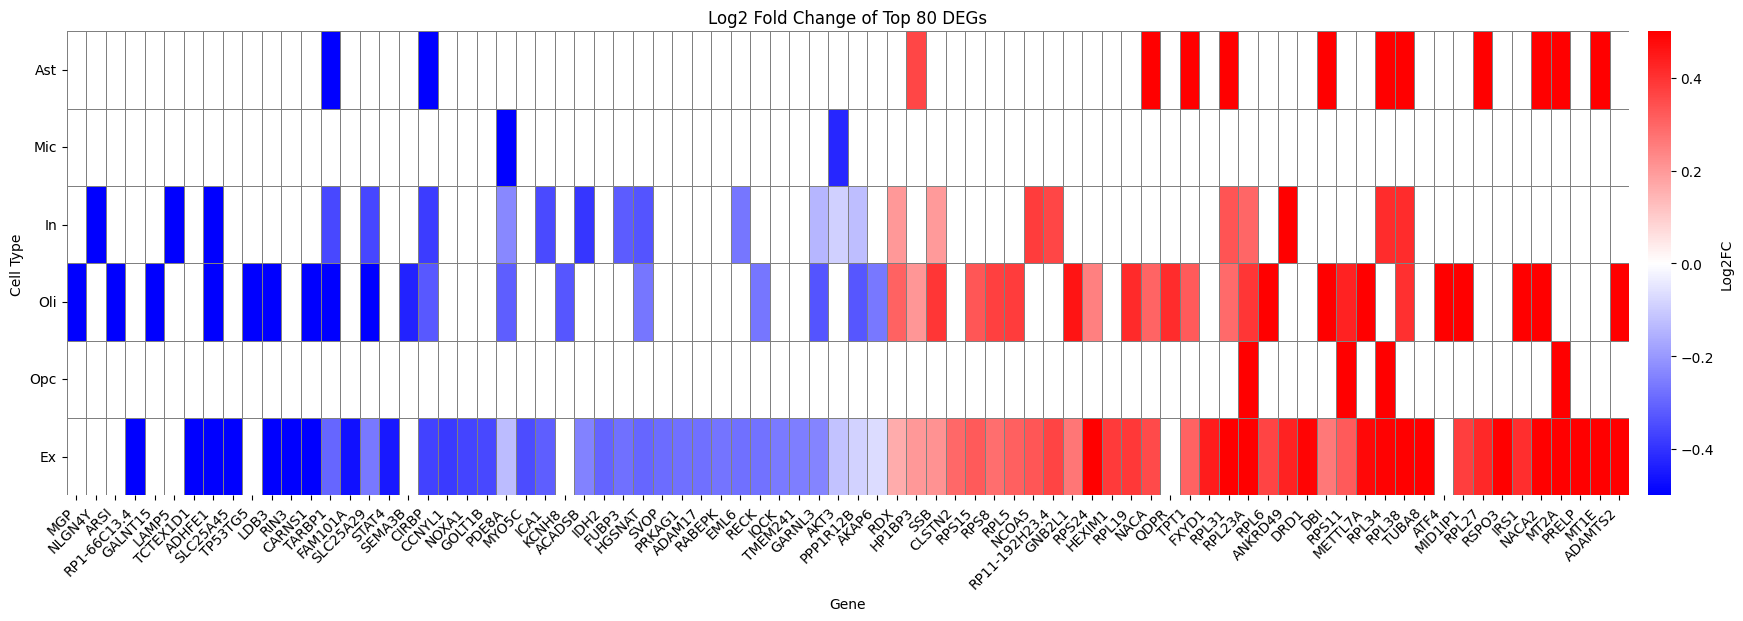

Horizontal heatmap saved to /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/heatmap_top50_genes_columns.png


In [5]:
# deg heatmap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# === Paths ===
de_base_dir = "/n/scratch/users/a/adm808/Revision/Clincal_batch_DE_Outputs_revision"
out_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/"
os.makedirs(out_dir, exist_ok=True)

# === Cell types ===
cell_types = ["Ast", "Mic", "In", "Oli", "Opc", "Ex"]
de_files = {
    "Ast": "poisson_DE_results_Ast.csv",
    "Mic": "poisson_DE_results_Mic.csv",
    "In": "poisson_DE_results_In.csv",
    "Oli": "poisson_DE_results_Oli.csv",
    "Opc": "poisson_DE_results_Opc.csv",
    "Ex": "poisson_DE_results_Ex.csv"
}

# === Collect log2FCs for all genes across cell types ===
gene_log2fc_dict = {}

for ct in cell_types:
    de_path = os.path.join(de_base_dir, de_files[ct])
    df = pd.read_csv(de_path)
    df = df[df["p_adj"] < 0.05]
    for _, row in df.iterrows():
        gene = row["gene"]
        if gene not in gene_log2fc_dict:
            gene_log2fc_dict[gene] = {}
        gene_log2fc_dict[gene][ct] = row["log2FC"]

# === Compute overall significance to select top 50 genes ===
all_dfs = []
for ct in cell_types:
    df = pd.read_csv(os.path.join(de_base_dir, de_files[ct]))
    df = df[df["p_adj"] < 0.05]
    all_dfs.append(df)
combined_df = pd.concat(all_dfs)
# combined_df_grouped = combined_df.groupby("gene")["p_adj"].min().reset_index()
# top_genes = combined_df_grouped.nsmallest(50, "p_adj")["gene"].tolist()
# Group by gene and take minimal p_adj
combined_df_grouped = combined_df.groupby("gene")["p_adj"].min().reset_index()

# Find genes with log2FC > 0.2 in at least one cell type
genes_with_large_fc = combined_df.groupby("gene")["log2FC"].apply(lambda x: np.max(np.abs(x)))
genes_with_large_fc = genes_with_large_fc[genes_with_large_fc > 0.25].index.tolist()

# Keep only those genes in combined_df_grouped
filtered_df = combined_df_grouped[combined_df_grouped["gene"].isin(genes_with_large_fc)]

# Pick top 50 by p_adj from this filtered set
top_genes = filtered_df.nsmallest(80, "p_adj")["gene"].tolist()

# === Build heatmap DataFrame ===
heatmap_df = pd.DataFrame(index=cell_types, columns=top_genes)

for gene in top_genes:
    for ct in cell_types:
        val = gene_log2fc_dict.get(gene, {}).get(ct, np.nan)
        heatmap_df.loc[ct, gene] = val

heatmap_df = heatmap_df.astype(float)

gene_means = heatmap_df.mean(axis=0)
sorted_genes = gene_means.sort_values().index.tolist()
heatmap_df = heatmap_df[sorted_genes]

# === Plot heatmap (genes = columns, cell types = rows) ===
plt.figure(figsize=(24, 8))  # Wide for many genes
sns.heatmap(
    heatmap_df,
    cmap="bwr",
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Log2FC', 'pad': 0.01},
    vmin=-0.5, vmax=0.5  # You can adjust after seeing
)
plt.title("Log2 Fold Change of Top 80 DEGs")
plt.xlabel("Gene")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Cell Type")
plt.yticks(rotation=0)
plt.subplots_adjust(bottom=0.3)  # Value between 0 and 1; larger = more space

plt.savefig(os.path.join(out_dir, "heatmap_top80_genes_columns.png"), dpi=300)
plt.show()

print(f"Horizontal heatmap saved to {os.path.join(out_dir, 'heatmap_top50_genes_columns.png')}")

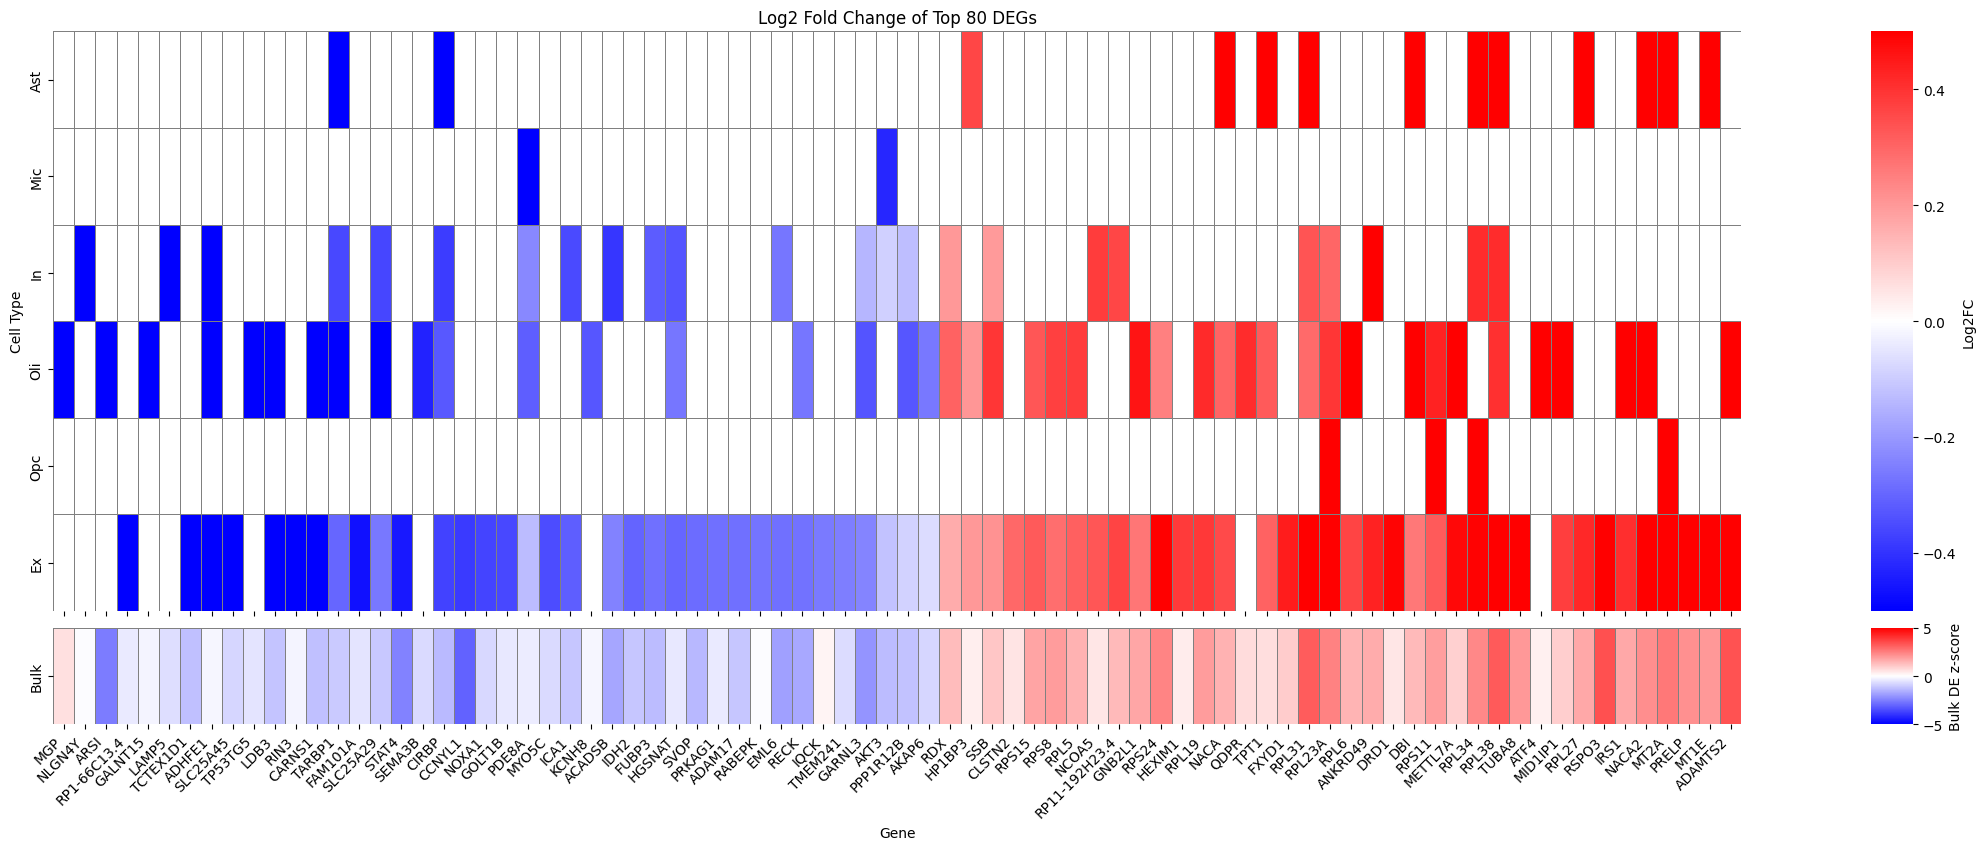

Saved: /n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Revision/Figure3/heatmap_top80_genes_with_bulk.png


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from matplotlib.gridspec import GridSpec
# import os

# # 0) Make sure column names are identical objects on both sides
# heatmap_df.columns = pd.Index([str(c).strip() for c in heatmap_df.columns])

# bulk_dir = "/n/groups/patel/adithya/Alz_Outputs/Final_Outputs/Final_Outputs_Figures/AD_prediction_stuff_new/Bulk/"
# z_path = os.path.join(bulk_dir, "zscore_directionality_matrix.csv")
# bulk_z = pd.read_csv(z_path)
# bulk_z["gene"] = bulk_z["gene"].astype(str).str.strip()

# # 1) Build Bulk row in *exact* same order (NaN -> white)
# bulk_row = bulk_z.set_index("gene")["Bulk"].reindex(heatmap_df.columns)
# bulk_heatmap = pd.DataFrame([bulk_row], index=["Bulk"])

# # 2) Combine, then split (columns guaranteed identical)
# combined = pd.concat([heatmap_df, bulk_heatmap], axis=0)
# top    = combined.iloc[:-1, :]
# bottom = combined.iloc[-1:, :]

# # 3) Plot with fixed-width colorbar columns (prevents axis width drift)
# fig = plt.figure(figsize=(24, 9))
# gs = GridSpec(nrows=2, ncols=2, width_ratios=[40, 1], height_ratios=[6, 1], hspace=0.05, wspace=0.15)

# ax1  = fig.add_subplot(gs[0, 0])
# cax1 = fig.add_subplot(gs[0, 1])   # colorbar for top
# ax2  = fig.add_subplot(gs[1, 0], sharex=ax1)
# cax2 = fig.add_subplot(gs[1, 1])   # colorbar for bottom

# # Top: CT log2FC
# sns.heatmap(
#     top, ax=ax1,
#     cmap="bwr", center=0,
#     linewidths=0.5, linecolor="gray",
#     cbar=True, cbar_ax=cax1,
#     cbar_kws={"label": "Log2FC", "pad": 0.02},
#     vmin=-0.5, vmax=0.5
# )
# ax1.set_title("Log2 Fold Change of Top 80 DEGs")

# # ax1.set_title("Cell-type log2FC (Top 80 DEGs)")
# ax1.set_ylabel("Cell Type")


# # Bottom: Bulk z
# sns.heatmap(
#     bottom, ax=ax2,
#     cmap="bwr", center=0,
#     linewidths=0.5, linecolor="gray",
#     cbar=True, cbar_ax=cax2,
#     cbar_kws={"label": "Bulk DE z-score", "pad": 0.02},
#     vmin=-5, vmax=5
# )

# ax2.set_xlabel("Gene")
# ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")
# ax2.set_ylabel("")

# # Hard-lock x-limits and tick positions to be identical
# ax2.set_xlim(ax1.get_xlim())
# ax2.set_xticks(np.arange(len(top.columns)) + 0.5)
# ax1.set_xticks(np.arange(len(top.columns)) + 0.5)

# ax1.tick_params(axis='x', labelbottom=False)

# out_path = os.path.join(out_dir, "heatmap_top80_genes_with_bulk.png")
# plt.savefig(out_path, dpi=300, bbox_inches="tight")
# plt.show()
# print(f"Saved: {out_path}")